## **Import Necessary Libraries and Modules**

In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score,
)
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression

SEED = 42

# **1. Load and Prepare Data**

In [65]:
df = pd.read_csv("../encoded_dataset.csv")

display(df.head())

,timestamp,age,year_of_study,gpa_range,currently_employed,leisure_hours,self_study_hours,sleep_hours,impact_on_learning_progress,far_away_deadlines,...,gender_Prefer not to say,college_CAS (Arts and Sciences),college_CBM (Business and Management),college_CECS (Engineering & Computer Science),college_CHS (Health Science),college_Non-VinUnian,study_environment_Collab Space,study_environment_Flexible/Multiple,study_environment_Open Space,study_environment_Private Space
0,2026-05-14 00:28:00,19,1,5,0,2.0,4.0,8.0,5,5,...,0,0,0,1,0,0,0,0,0,1
1,2026-05-14 00:30:30,19,1,5,1,2.0,8.0,7.0,7,6,...,0,0,1,0,0,0,0,0,0,1
2,2026-05-14 00:30:32,19,1,4,0,4.0,3.0,6.0,5,6,...,0,0,0,1,0,0,0,0,1,0
3,2026-05-14 00:32:25,19,1,4,0,5.0,4.0,7.0,7,6,...,0,0,0,1,0,0,0,0,0,1
4,2026-05-14 00:33:32,23,1,5,0,4.0,1.0,5.0,6,7,...,0,0,0,0,1,0,0,0,0,1


# **2. Feature and Binary Target Selection**

In [66]:
# ------------------- Binary Target Selection -----------------------
# >= 4 is 1 (procrastinate), < 4 is 0 (does not procrastinate)
target_feature = "delay_until_deadline"
y = (df[target_feature] >= 5).astype(int)


# ------------------- Feature Selection -----------------------------
drop_features = ["delay_until_deadline",
                 "timestamp",
                 "referrer",
                 "data_quality_check",
                 "delay_unenjoyable_assignments",
                 "far_away_deadlines"]

# Demographic features
demographic_features = ["age", "year_of_study", "gpa_range", "currently_employed",
                        "leisure_hours", "self_study_hours", "sleep_hours",
                        "gender_Female", "gender_Male", "gender_Other", "gender_Prefer not to say",
                        "college_CAS (Arts and Sciences)", "college_CBM (Business and Management)",
                        "college_CECS (Engineering & Computer Science)",
                        "college_CHS (Health Science)", "college_Non-VinUnian",
                        "study_environment_Collab Space", "study_environment_Flexible/Multiple",
                        "study_environment_Open Space", "study_environment_Private Space"]

behavioral_features = df.drop(columns = demographic_features + drop_features).columns.tolist()

# Create the feature matrix X
X = df[demographic_features + behavioral_features]
display(X.head())

,age,year_of_study,gpa_range,currently_employed,leisure_hours,self_study_hours,sleep_hours,gender_Female,gender_Male,gender_Other,...,study_environment_Private Space,impact_on_learning_progress,study_plan,start_early_when_necessary,difficult_to_maintain,comfort_or_convenience,peers_consider_normal,control_over_habit,sooner_next_month,focus_frequency
0,19,1,5,0,2.0,4.0,8.0,0,1,0,...,1,5,4,6,5,6,5,5,4,5.0
1,19,1,5,1,2.0,8.0,7.0,1,0,0,...,1,7,7,7,1,1,3,4,7,4.0
2,19,1,4,0,4.0,3.0,6.0,0,1,0,...,0,5,6,4,2,3,3,4,4,3.0
3,19,1,4,0,5.0,4.0,7.0,0,1,0,...,1,7,6,6,4,7,3,4,1,5.0
4,23,1,5,0,4.0,1.0,5.0,0,1,0,...,1,6,5,3,6,6,6,5,4,5.0


# **3. Train/Test Split and Feature Scaling**

In [67]:
# ─────────────────────────────────────────────
# 2. Perform stratified train-test split
# ─────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.5, stratify=y, random_state=42
)

print(f"Number of training samples is: {X_train.shape[0]}")
print(f"Number of testing_samples is: {X_test.shape[0]}")

# Scale features
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

Number of training samples is: 96
Number of testing_samples is: 97


# **4. Logistic Regression**

### **Function to determine the optimized threshold and optimized probability prediction**

In [68]:
def predict_maximize_gmean(model, X, y_true):

    # 1. Get predicted probabilities for the positive class (column 1)
    y_scores = model.predict_proba(X)[:, 1]

    # Scenario A: We are calculating the optimal threshold dynamically (e.g., on a validation set)
    if y_true is not None:
        # Calculate True Positive Rate (Sensitivity) and False Positive Rate across thresholds
        fpr, tpr, thresholds = roc_curve(y_true, y_scores)

        # Specificity is 1 - False Positive Rate
        specificity = 1 - fpr

        # Calculate G-Mean: sqrt(Sensitivity * Specificity)
        gmeans = np.sqrt(tpr * specificity)

        # Locate the index of the maximum G-Mean
        best_idx = np.argmax(gmeans)
        optimal_threshold = thresholds[best_idx]

        # Handle edge case where roc_curve arbitrarily sets the first threshold above 1.0
        if optimal_threshold > 1.0:
            optimal_threshold = 1.0

    # 2. Apply the optimal threshold to binarize predictions
    y_pred = (y_scores >= optimal_threshold).astype(int)

    return y_pred, optimal_threshold

### **Baseline model**

In [69]:
logistic_regression_baseline = LogisticRegression(max_iter=1000, solver="liblinear")
logistic_regression_baseline.fit(X_train, y_train)
# Baseline AUC
print(
    f"Train AUC: {roc_auc_score(y_train, logistic_regression_baseline.predict_proba(X_train)[:, 1])}"
)
print(
    f"Test AUC: {roc_auc_score(y_test, logistic_regression_baseline.predict_proba(X_test)[:, 1])}"
)
y_pred, threshold = predict_maximize_gmean(logistic_regression_baseline, X_test, y_test)
print(f"Confusion matrix (test), threshold = {threshold}:")
print(confusion_matrix(y_test, y_pred))

Train AUC: 0.9052173913043479
Test AUC: 0.789002557544757
Confusion matrix (test), threshold = 0.7005671356191436:
[[44  7]
 [16 30]]


In [70]:
logistic_regression_scaled = LogisticRegression(max_iter=1000, solver="liblinear")
logistic_regression_scaled.fit(X_train_sc, y_train)
# Scaled AUC
print(
    f"Train AUC: {roc_auc_score(y_train, logistic_regression_scaled.predict_proba(X_train_sc)[:, 1])}"
)
print(
    f"Test AUC: {roc_auc_score(y_test, logistic_regression_scaled.predict_proba(X_test_sc)[:, 1])}"
)
y_pred, threshold = predict_maximize_gmean(
    logistic_regression_scaled, X_test_sc, y_test
)
print(f"Confusion matrix (test), threshold = {threshold}:")
print(confusion_matrix(y_test, y_pred))

Train AUC: 0.9173913043478261
Test AUC: 0.7988064791133844
Confusion matrix (test), threshold = 0.4565614693874869:
[[37 14]
 [10 36]]


### **Hyperparameters Tuning**

In [71]:
def train_logistic(**kwargs):
    model = LogisticRegression(max_iter=1000, **kwargs)
    model.fit(X_train_sc, y_train)
    return model

The optimum regularization strength c is: 1e-05


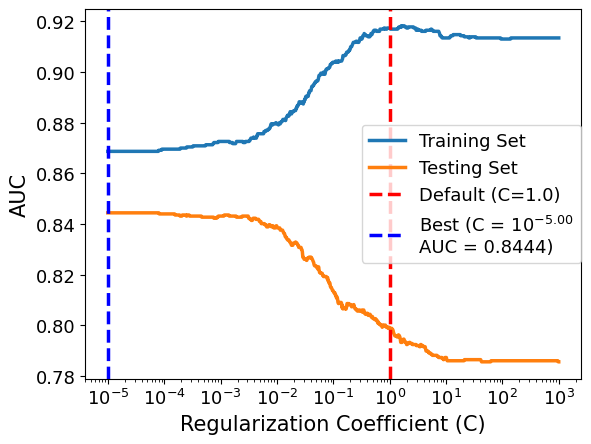

In [72]:
# Vary regularization strength for L2 regularization
auc_df = pd.DataFrame(columns=["C", "Training Set", "Testing Set"])
for C in np.logspace(-5, 3, 1000):
    model = train_logistic(C=C, solver="liblinear")
    auc_df.loc[len(auc_df)] = [
        C,
        roc_auc_score(y_train, model.predict_proba(X_train_sc)[:, 1]),
        roc_auc_score(y_test, model.predict_proba(X_test_sc)[:, 1]),
    ]

best_auc_idx = auc_df["Testing Set"].idxmax();
best_c_l2 = auc_df.loc[best_auc_idx, "C"]
c_exp_l2 = np.log10(best_c_l2)
best_auc = auc_df.loc[best_auc_idx, "Testing Set"]
print(f"The optimum regularization strength c is: {best_c_l2}")

# ----------------------- Visualize AUC by Regularization Strength ----------------------
ax = auc_df.plot.line(x="C", logx=True, linewidth = 2.5)
ax.axvline(x=1.0, color='red', linestyle='--', label='Default (C=1.0)', linewidth = 2.5)
ax.axvline(x = best_c_l2, color = 'blue', linestyle = '--', label = f"Best (C = $10^{{{c_exp_l2:.2f}}}$\nAUC = {best_auc:.4f})", linewidth = 2.5)
ax.set_ylabel("AUC", fontsize = 15)
ax.set_xlabel("Regularization Coefficient (C)", fontsize = 15)
ax.tick_params(axis = "both", labelsize = 13)
ax.legend(loc='best', borderaxespad=0, fontsize = 13)


plt.savefig("../figures/l2_logistic_auc.pdf", bbox_inches="tight")

The optimum regularization strength c is: 0.15710723892474487


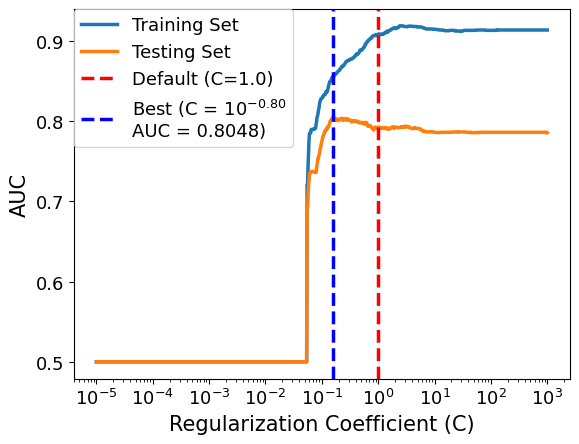

In [73]:
# Vary regularization strength for L2 regularization
auc_df = pd.DataFrame(columns=["C", "Training Set", "Testing Set"])
for C in np.logspace(-5, 3, 1000):
    model = train_logistic(C=C, l1_ratio = 1, solver="liblinear")
    auc_df.loc[len(auc_df)] = [
        C,
        roc_auc_score(y_train, model.predict_proba(X_train_sc)[:, 1]),
        roc_auc_score(y_test, model.predict_proba(X_test_sc)[:, 1]),
    ]

best_auc_idx = auc_df["Testing Set"].idxmax();
best_c_l1 = auc_df.loc[best_auc_idx, "C"]
c_exp_l1 = np.log10(best_c_l1)
best_auc = auc_df.loc[best_auc_idx, "Testing Set"]
print(f"The optimum regularization strength c is: {best_c_l1}")

# ----------------------- Visualize AUC by Regularization Strength ----------------------
ax = auc_df.plot.line(x="C", logx=True, linewidth = 2.5)
ax.axvline(x=1.0, color='red', linestyle='--', label='Default (C=1.0)', linewidth = 2.5)
ax.axvline(x = best_c_l1, color = 'blue', linestyle = '--', label = f"Best (C = $10^{{{c_exp_l1:.2f}}}$\nAUC = {best_auc:.4f})", linewidth = 2.5)
ax.set_ylabel("AUC", fontsize = 15)
ax.set_xlabel("Regularization Coefficient (C)", fontsize = 15)
ax.tick_params(axis = "both", labelsize = 13)
ax.legend(loc='best', borderaxespad=0, fontsize = 13)
plt.savefig("../figures/l1_logistic_auc.pdf", bbox_inches="tight")

**Best Configuration for Logistic Regression**

&rarr; C = 10e-5.00, L2 Regularization

# 5. **SVM Model**

In [74]:
def train_svm(**kwargs):
    model = SVC(probability=True, random_state=SEED, **kwargs)
    model.fit(X_train_sc, y_train)
    return model

### **Hyperparameter Tuning**

The optimum regularization strength c is: 0.004258518291843414


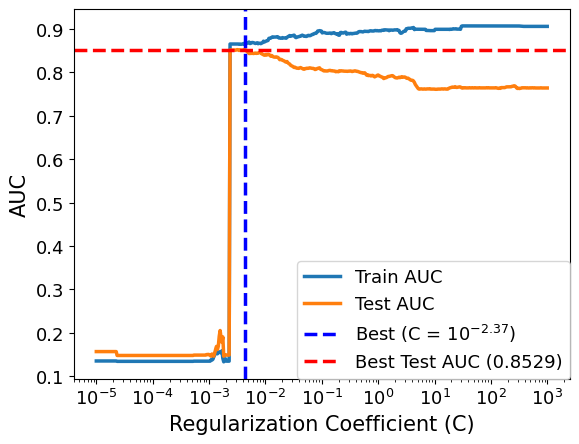

In [83]:
# Vary regularization strength for linear kernel
auc_df = pd.DataFrame(columns=["C", "Train AUC", "Test AUC"])
for C in np.logspace(-5, 3, 500):
    model = train_svm(C=C, kernel = "linear", gamma = "scale")
    auc_df.loc[len(auc_df)] = [
        C,
        roc_auc_score(y_train, model.predict_proba(X_train_sc)[:, 1]),
        roc_auc_score(y_test, model.predict_proba(X_test_sc)[:, 1]),
    ]


best_auc_idx = auc_df["Test AUC"].idxmax()
best_auc = auc_df.loc[best_auc_idx, "Test AUC"]
best_c_linear_svm = auc_df.loc[best_auc_idx, "C"]
c_exp_svm_l2 = np.log10(best_c_linear_svm)
print(f"The optimum regularization strength c is: {best_c_linear_svm}")

# ----------------------- Visualize AUC by Regularization Strength ----------------------
ax = auc_df.plot.line(x="C", logx=True, linewidth = 2.5)
# ax.axvline(x=1.0, color='red', linestyle='--', label='Default (C=1.0)')
ax.axvline(x = best_c_linear_svm, color = 'blue', linestyle = '--', label = f"Best (C = $10^{{{c_exp_svm_l2:.2f}}}$)", linewidth = 2.5)
ax.axhline(y = best_auc, color = 'red', linestyle = '--', label = f'Best Test AUC ({best_auc:.4f})', linewidth = 2.5)
ax.set_xlabel('Regularization Coefficient (C)', fontsize=15)
ax.set_ylabel('AUC', fontsize=15)
ax.tick_params(axis = "both", labelsize = 13)
ax.legend(loc='best', borderaxespad=0, fontsize = 13)
plt.savefig("../figures/linear_svm_auc.pdf", bbox_inches="tight")

The optimum regularization strength c is: 0.27598263924661803


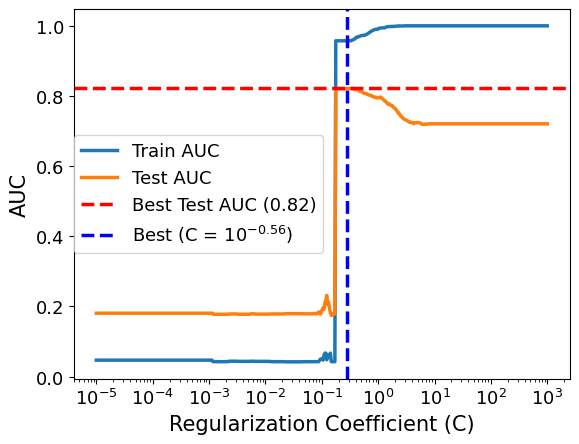

In [76]:
# Vary regularization strength for rbf kernel
auc_df = pd.DataFrame(columns=["C", "Train AUC", "Test AUC"])
for C in np.logspace(-5, 3, 500):
    model = train_svm(C=C, kernel = "rbf", gamma = "scale")
    auc_df.loc[len(auc_df)] = [
        C,
        roc_auc_score(y_train, model.predict_proba(X_train_sc)[:, 1]),
        roc_auc_score(y_test, model.predict_proba(X_test_sc)[:, 1]),
    ]


best_auc_idx = auc_df["Test AUC"].idxmax()
best_auc = auc_df.loc[best_auc_idx, "Test AUC"]
best_c_rbf_svm = auc_df.loc[best_auc_idx, "C"]
c_exp_rbf_l2 = np.log10(best_c_rbf_svm)
print(f"The optimum regularization strength c is: {best_c_rbf_svm}")

# ----------------------- Visualize AUC by Regularization Strength ----------------------
ax = auc_df.plot.line(x="C", logx=True, linewidth = 2.5)
ax.axhline(y = best_auc, color = 'red', linestyle = '--', label = f'Best Test AUC ({best_auc:.2f})', linewidth = 2.5)
ax.axvline(x = best_c_rbf_svm, color = 'blue', linestyle = '--', label = f"Best (C = $10^{{{c_exp_rbf_l2:.2f}}}$)", linewidth = 2.5)
ax.set_xlabel('Regularization Coefficient (C)', fontsize=15)
ax.set_ylabel('AUC', fontsize=15)
ax.tick_params(axis = "both", labelsize = 13)
ax.legend(loc='best', borderaxespad=0, fontsize = 13)
plt.savefig("../figures/rbf_svm_auc.pdf", bbox_inches="tight")

**Best Configuration for SVM**

&rarr; C = 10e-2.37, Kernel Linear

## **Final Evaluation**

### **Find optimal threshold for models (Since ROC-AUC evaluate on all thresholds)**

In [77]:
best_logreg_model = train_logistic(l1_ratio = 0, C = best_c_l2, solver = "liblinear")
best_svm_model = train_svm(kernel = "linear", C = best_c_linear_svm, gamma = "scale")

logreg_pred_optimal, logreg_threshold_optimal = predict_maximize_gmean(best_logreg_model, X_test_sc, y_test)
svm_pred_optimal, svm_threshold_optimal = predict_maximize_gmean(best_svm_model, X_test_sc, y_test)


print(f"Optimal threshold for Logistic Regression is {logreg_threshold_optimal}")
print(f"Optimal threshold for SVM is {svm_threshold_optimal}")

Optimal threshold for Logistic Regression is 0.5000219001197223
Optimal threshold for SVM is 0.44752395828513347


In [78]:
# ─────────────────────────────────────────────
# 4. Metrics
# ─────────────────────────────────────────────
def get_metrics(y_true, y_pred, label=""):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    print(f"\n{'─' * 40}")
    print(f"  {label} Metrics")
    print(f"{'─' * 40}")
    print(f"  Accuracy  : {acc:.4f}")
    print(f"  Precision : {prec:.4f}")
    print(f"  Recall    : {rec:.4f}")
    print(f"  F1-Score  : {f1:.4f}")
    return acc, prec, rec, f1


### **Evaluate metrics of two models using with their optimized threshold**

In [79]:
# =====================================================
# FINAL COMPARISON: BEST LOGREG vs BEST SVM
# Using Optimized Thresholds
# =====================================================

print("\n" + "="*70)
print("FINAL MODEL COMPARISON (Test Set with Optimized Thresholds)")
print("="*70)

# Get metrics for Logistic Regression
logreg_acc, logreg_prec, logreg_rec, logreg_f1 = get_metrics(
    y_test, 
    logreg_pred_optimal, 
    f"Logistic Regression (L2, C={best_c_l2:.6f}, threshold={logreg_threshold_optimal:.4f})"
)

# Get metrics for SVM
svm_acc, svm_prec, svm_rec, svm_f1 = get_metrics(
    y_test, 
    svm_pred_optimal, 
    f"SVM (Linear, C={best_c_linear_svm:.6f}, threshold={svm_threshold_optimal:.4f})"
)

# Step 5: Comparison Table
print(f"\n{'='*70}")
print("METRICS COMPARISON TABLE")
print(f"{'='*70}\n")

comparison_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'SVM (Linear)'],
    'Accuracy': [f"{logreg_acc:.4f}", f"{svm_acc:.4f}"],
    'Precision': [f"{logreg_prec:.4f}", f"{svm_prec:.4f}"],
    'Recall': [f"{logreg_rec:.4f}", f"{svm_rec:.4f}"],
    'F1-Score': [f"{logreg_f1:.4f}", f"{svm_f1:.4f}"]
})

print(comparison_df.to_string(index=False))

# Step 6: Determine Winner
print(f"\n{'='*70}")
print("WINNER ANALYSIS")
print(f"{'='*70}\n")

if svm_f1 > logreg_f1:
    print(f"✓ SVM (Linear) is the BETTER model")
    print(f"  - F1-Score: {svm_f1:.4f} vs {logreg_f1:.4f} (+{(svm_f1-logreg_f1):.4f})")
else:
    print(f"✓ Logistic Regression is the BETTER model")
    print(f"  - F1-Score: {logreg_f1:.4f} vs {svm_f1:.4f} (+{(logreg_f1-svm_f1):.4f})")

print(f"\nOther metrics:")
print(f"  Accuracy:  LR={logreg_acc:.4f}, SVM={svm_acc:.4f}")
print(f"  Precision: LR={logreg_prec:.4f}, SVM={svm_prec:.4f}")
print(f"  Recall:    LR={logreg_rec:.4f}, SVM={svm_rec:.4f}")

# Step 7: Confusion Matrices
print(f"\n{'='*70}")
print("CONFUSION MATRICES")
print(f"{'='*70}\n")

print("Logistic Regression:")
print(confusion_matrix(y_test, logreg_pred_optimal))

print("\nSVM (Linear):")
print(confusion_matrix(y_test, svm_pred_optimal))



FINAL MODEL COMPARISON (Test Set with Optimized Thresholds)

────────────────────────────────────────
  Logistic Regression (L2, C=0.000010, threshold=0.5000) Metrics
────────────────────────────────────────
  Accuracy  : 0.8144
  Precision : 0.8333
  Recall    : 0.7609
  F1-Score  : 0.7955

────────────────────────────────────────
  SVM (Linear, C=0.004259, threshold=0.4475) Metrics
────────────────────────────────────────
  Accuracy  : 0.8144
  Precision : 0.7500
  Recall    : 0.9130
  F1-Score  : 0.8235

METRICS COMPARISON TABLE

              Model Accuracy Precision Recall F1-Score
Logistic Regression   0.8144    0.8333 0.7609   0.7955
       SVM (Linear)   0.8144    0.7500 0.9130   0.8235

WINNER ANALYSIS

✓ SVM (Linear) is the BETTER model
  - F1-Score: 0.8235 vs 0.7955 (+0.0281)

Other metrics:
  Accuracy:  LR=0.8144, SVM=0.8144
  Precision: LR=0.8333, SVM=0.7500
  Recall:    LR=0.7609, SVM=0.9130

CONFUSION MATRICES

Logistic Regression:
[[44  7]
 [11 35]]

SVM (Linear):
[[37

### **Top features based on coefficients**

In [80]:
best_svm_model.coef_
feature_coef_table = {"Feature" : [], "Coefficients" : [], "Absolute Coefficients" : []}
for index, feature in enumerate(X.columns.tolist()):
    feature_coef_table["Feature"].append(feature)
    feature_coef_table["Coefficients"].append(best_svm_model.coef_[0][index])
    feature_coef_table["Absolute Coefficients"].append(abs(best_svm_model.coef_[0][index]))

feature_coef_table

feature_coef_df = pd.DataFrame(feature_coef_table)

In [81]:
print("Top 5 Demographic Features")
display(feature_coef_df[feature_coef_df["Feature"].isin(demographic_features)].sort_values(by = "Absolute Coefficients", ascending = False)[:5])

Top 5 Demographic Features


,Feature,Coefficients,Absolute Coefficients
5,self_study_hours,-0.138729,0.138729
4,leisure_hours,0.103656,0.103656
1,year_of_study,-0.076061,0.076061
12,college_CBM (Business and Management),0.072269,0.072269
15,college_Non-VinUnian,-0.053441,0.053441


In [82]:
print("Top 5 most Behavioral Features")
display(feature_coef_df[feature_coef_df["Feature"].isin(behavioral_features)].sort_values(by = "Absolute Coefficients", ascending = False)[:5])

Top 5 most Behavioral Features


,Feature,Coefficients,Absolute Coefficients
23,difficult_to_maintain,0.142763,0.142763
24,comfort_or_convenience,0.116480,0.116480
20,impact_on_learning_progress,0.095747,0.095747
22,start_early_when_necessary,-0.083172,0.083172
25,peers_consider_normal,0.056138,0.056138
